In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm.auto import tqdm
from quantum_reservoir import(
    QuantumReservoir,
    ReadoutConfig,
    HamiltonianConfig
)

# Univariate Fully-Conected Quantum Ising Model

The Quantum Reservoir (QR) is based on a fully-connected transverse-field Ising model. The protocol starts with the initialization in the pure product state:

$$
\rho_0 = |+\rangle^{\otimes N} \langle +|^{\otimes N}.
$$

Then, a normalized scalar input $x_l\in [0,1]$ is encoded into the quantum reservoir by updating the density matrix as it follows:

$$
\rho \mapsto |\psi(x_l)\rangle \langle \psi(x_l)| \otimes \text{Tr}_0[\rho],
$$

where:

$$
|\psi(x_l)\rangle = \sqrt{1-x_l}|0\rangle + \sqrt{x_l}|1\rangle.
$$

This way, at each step, the first qubit is overwriten with a stated that contains information about the new input throught amplitude encoding.

Thereafter, the system evolves under the time-independent Hamiltonian:

$$
H=\sum_{i<j}J_{i,j} X_i X_j + \sum_i h_i Z_i,
$$

where $X_i$ and $Z_i$ are Pauli operators acting on qubit $i$, $J_{i,j}$ represents inter-qubit couplings and $h_i$ represents local transverse magnetic fields.

The state evolves through $V$ uniformly spaced time intervals, referred to as virtual nodes, during which the observables

$$
\langle Z_i(t_k) \rangle = \operatorname{Tr}[Z_i \rho(t_k)]
$$

are measured. The resulting measurements form a feature vector of dimension $V \times n_{\text{qubits}}$ for each input $x_l$. After processing a full input window, the linear readout weights are trained using Ridge regression, which minimizes the mean squared error between predictions and targets while penalizing large weight values. The optimization problem is

$$
W^{*}
=
\arg\min_W
\left(
\|Y-XW\|_F^2
+
\lambda\|W\|_F^2
\right),
$$

where $\lambda \geq 0$ controls the strength of the regularization. The closed-form solution is

$$
W^{*}
=
\left(
X^\top X+\lambda I
\right)^{-1}
X^\top Y.
$$

The final readout layer can therefore be expressed as

$$
\hat{Y}=XW^{*},
$$

where $X$ contains the reservoir features, $W^{*}$ contains the trained readout weights, and $\hat{Y}$ contains the predictions.

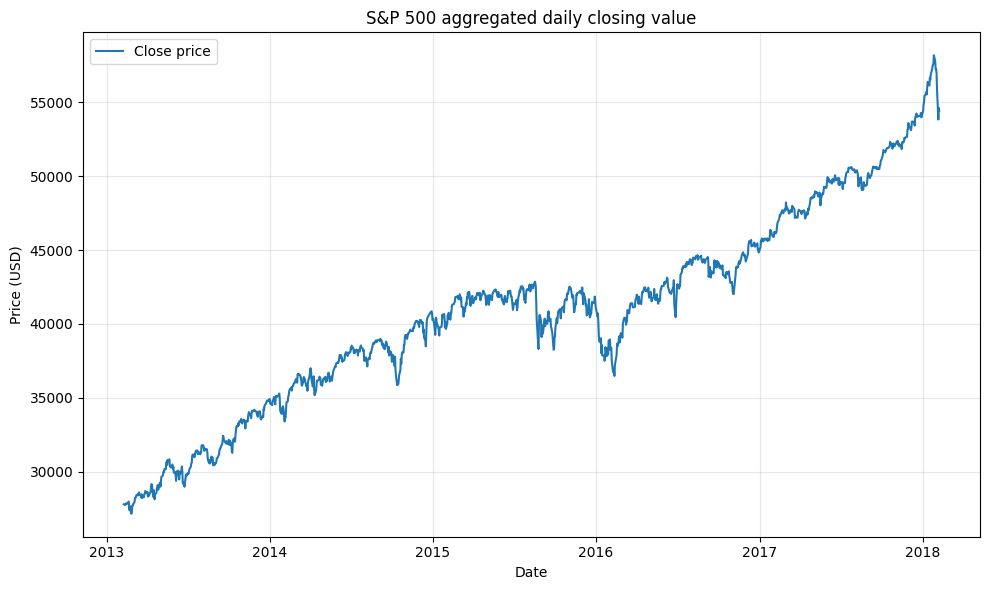

In [3]:
# ===========================================================================
# IMPORT AND PLOT DATA
# ===========================================================================

df = pd.read_csv("../data/aggregated_data.csv")
df["date"] = pd.to_datetime(df["date"])

# Plot the time series
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["date"], df["close"], label="Close price")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("S&P 500 aggregated daily closing value")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# ===========================================================================
# DEFINE THE RESERVOIR
# ===========================================================================

hamiltonian = HamiltonianConfig(
    J_mode="const",
    J_value=0.5,
    h_mode="uniform",
    h_min=0.1,
    h_max=1.0,
    initial_state="plus",
)

readout = ReadoutConfig(
    method="ridge",
    ridge=0.8
)

def initialize_qreservoir(seed):
    return QuantumReservoir(
        n_qubits=6,
        t=0.3,
        n_vnodes=2,
        window_size=4,
        horizon=25,
        observables="Z",
        hamiltonian=hamiltonian,
        readout=readout,
        washout_mode="discard",
        washout_steps=0,
        seed=seed,
    )

In [ ]:
# ===========================================================================
# RUN THE QUANTUM RESERVOIR EXPERIMENT
# ===========================================================================

data = df["close"].to_numpy(dtype=float)

n_seeds = 200
tmin, tmax = 1100, 1200
t_range = range(tmin, tmax)

reservoir = initialize_qreservoir(1)
horizon, window_size = reservoir.horizon, reservoir.window_size

# Keep only the data needed for the last forecast horizon
max_data_index = tmax + horizon
data = data[:max_data_index]

# Note: the class already takes care of normalizing and denormalizing
# data, but here we do it before to obtain the MAE values in the same
# range as in the paper.

# Normalize prices to [0, 1]
data_unit = (data - data.min()) / (data.max() - data.min())
data = data_unit

mae_all = []
mse_all = []

# Evaluate each seed across all forecast origins
seed_iterator = tqdm(
    range(n_seeds),
    desc="Seeds",
    position=0,
    dynamic_ncols=True,
)

for seed in seed_iterator:
    qreservoir = initialize_qreservoir(seed)
    mae_seed = []
    mse_seed = []

    for t in t_range:

        qreservoir.fit(data, train_end=t)
        
        preds = qreservoir.forecast()

        y_test = data[
            t + 1:
            t + 1 + qreservoir.horizon
        ]

        mae_seed.append(
            np.abs(preds - y_test)
        )
        mse_seed.append(
            (preds - y_test) ** 2
        )

    mae_all.append(mae_seed)
    mse_all.append(mse_seed)

mae_all = np.asarray(mae_all)  # (n_seeds, |t_range|, horizon)
mse_all = np.asarray(mse_all)  # (n_seeds, |t_range|, horizon)

In [5]:
# ===========================================================================
# DEFINE THE LINEAR BASELINE
# ===========================================================================

def linear_baseline_forecast(
    data: np.ndarray,
    train_end: int,
    window_size: int = 4,
    horizon: int = 25,
) -> np.ndarray:
    X_train = []
    y_train = []

    n_samples = train_end - window_size - horizon + 2

    for i in range(n_samples):
        X_train.append(
            data[i:i + window_size]
        )
        y_train.append(
            data[
                i + window_size:
                i + window_size + horizon
            ]
        )

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)

    # Add an intercept term
    X_train = np.column_stack([
        np.ones(len(X_train)),
        X_train,
    ])

    # Fit weights with the Moore–Penrose pseudoinverse
    W = np.linalg.pinv(X_train) @ y_train

    # Use the last training window for the forecast
    x_test = data[
        train_end - window_size + 1:
        train_end + 1
    ]

    x_test = np.concatenate([
        np.ones(1),
        x_test,
    ])

    return x_test @ W

In [6]:
# ===========================================================================
# EVALUATE THE LINEAR BASELINE
# ===========================================================================

mae_baseline = []
mse_baseline = []

for t in t_range:
    baseline_preds = linear_baseline_forecast(
        data,
        train_end=t,
        window_size=4,
        horizon=horizon,
    )

    y_test = data[
        t + 1:
        t + 1 + horizon
    ]

    mae_baseline.append(
        np.abs(baseline_preds - y_test)
    )
    mse_baseline.append(
        (baseline_preds - y_test) ** 2
    )

# Average errors over all forecast origins
mae_baseline = np.asarray(mae_baseline) # (|t_range|, horizon)
mse_baseline = np.asarray(mse_baseline) # (|t_range|, horizon)
baseline_mae = mae_baseline.mean(axis=0)  # (horizon,)
baseline_mse = mse_baseline.mean(axis=0)  # (horizon,)

In [7]:
# ===========================================================================
# AGGREGATE THE QUANTUM RESERVOIR RESULTS
# ===========================================================================

horizons = np.arange(1, qreservoir.horizon + 1)

# Average over forecast origins for each seed
mae_per_seed = mae_all.mean(axis=1) # (n_seeds, horizon)
mse_per_seed = mse_all.mean(axis=1) # (n_seeds, horizon)

# Compute statistics across seeds
mean_mae_per_step = mae_per_seed.mean(axis=0) # (horizon,)
mean_mse_per_step = mse_per_seed.mean(axis=0) # (horizon,)

std_mae_per_step = mae_per_seed.std(axis=0, ddof=1)  # (horizon,)
std_mse_per_step = mse_per_seed.std(axis=0, ddof=1)  # (horizon,)

# Define the one-standard-deviation bands
lower_bound_mae = mean_mae_per_step - std_mae_per_step
upper_bound_mae = mean_mae_per_step + std_mae_per_step

lower_bound_mse = mean_mse_per_step - std_mse_per_step
upper_bound_mse = mean_mse_per_step + std_mse_per_step

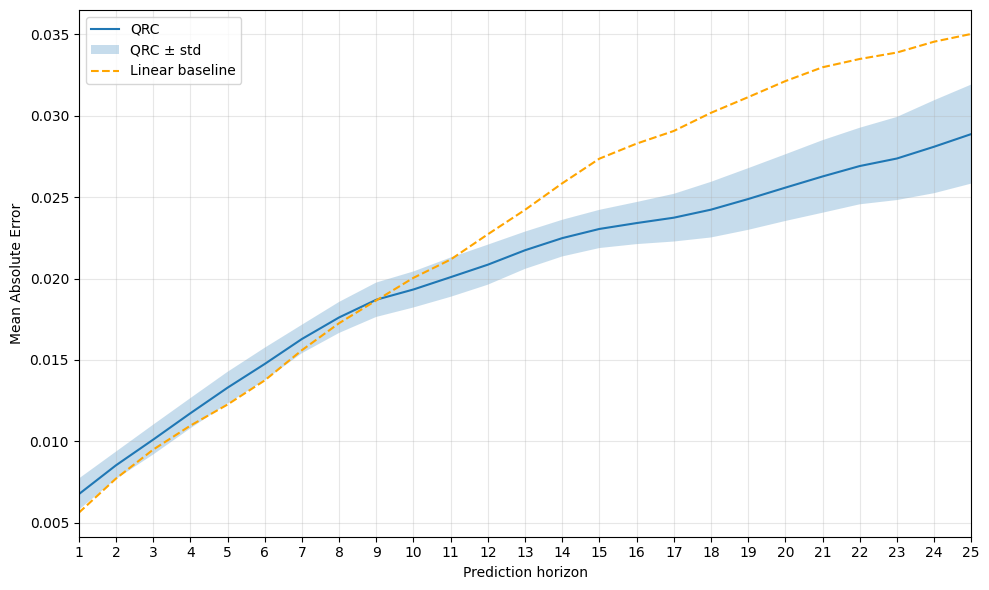

In [8]:
# ===========================================================================
# PLOT FORECAST ERRORS
# ===========================================================================

# MAE
plt.figure(figsize=(10, 6))

plt.plot(
    horizons,
    mean_mae_per_step,
    color="tab:blue",
    label="QRC",
)

plt.fill_between(
    horizons,
    lower_bound_mae,
    upper_bound_mae,
    alpha=0.25,
    label="QRC ± std",
)

plt.plot(
    horizons,
    baseline_mae,
    linestyle="--",
    color="orange",
    label="Linear baseline",
)

plt.xlabel("Prediction horizon")
plt.ylabel("Mean Absolute Error")
plt.xticks(horizons)
plt.xlim(1, qreservoir.horizon)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Uncomment the block below to plot MSE

# plt.figure(figsize=(10, 6))

# plt.plot(
#     horizons,
#     mean_mse_per_step,
#     color="tab:blue",
#     label="QRC",
# )

# plt.fill_between(
#     horizons,
#     lower_bound_mse,
#     upper_bound_mse,
#     alpha=0.25,
#     label="QRC ± std",
# )

# plt.plot(
#     horizons,
#     baseline_mse,
#     linestyle="--",
#     color="orange",
#     label="Linear baseline",
# )

# plt.xlabel("Prediction horizon")
# plt.ylabel("Mean Squared Error")
# plt.xticks(horizons)
# plt.xlim(1, qreservoir.horizon)
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()